# DINOv2/v3 前景分割 - CPU 测试版

本 notebook 演示如何使用 DINO 特征训练一个简单的前景分割模型。

**关于模型访问：**
- **DINOv2**: 公开可用，无需申请（本 notebook 使用）
- **DINOv3**: 需要申请权限 → [申请地址](https://ai.meta.com/resources/models-and-libraries/dinov3-downloads/)

**适用环境：**
- AMD Ryzen CPU (无 CUDA)
- 32GB 内存

**学习目标：**
1. 理解如何提取图像的 patch 特征
2. 学习线性探测 (Linear Probing) 方法
3. 训练一个简单的前景分割器

## 1. 环境配置

In [17]:
import io
import os
import pickle
import tarfile
import urllib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score
from tqdm import tqdm

import torch
import torchvision.transforms.functional as TF
from transformers import AutoModel, AutoImageProcessor

print(f"PyTorch 版本: {torch.__version__}")
print(f"使用设备: CPU")

PyTorch 版本: 2.10.0+cpu
使用设备: CPU


## 2. 加载模型

我们使用 ViT-S/Small 模型，适合 CPU 推理。

| 模型 | 参数量 | 特征维度 | CPU 速度 |
|------|--------|---------|----------|
| ViT-S/Small | 22M | 384 | ~0.5s |
| ViT-B/Base | 86M | 768 | ~1.5s |

**注意**: HuggingFace `AutoImageProcessor` 会自动确定图像大小，我们在下一步会动态检测。

In [18]:
# 使用 Hugging Face DINOv2 (公开可用)
HF_MODEL = 'facebook/dinov2-small'

print(f"正在加载模型: {HF_MODEL}")
print("(首次下载约 80MB，请耐心等待)")

processor = AutoImageProcessor.from_pretrained(HF_MODEL)
model = AutoModel.from_pretrained(HF_MODEL)
model.eval()

# 模型参数
total_params = sum(p.numel() for p in model.parameters())
FEATURE_DIM = 384  # ViT-S/Small 特征维度
PATCH_SIZE = 16

print(f"\n✓ 模型加载完成!")
print(f"  参数量: {total_params / 1e6:.1f}M")
print(f"  特征维度: {FEATURE_DIM}")
print(f"  Patch 大小: {PATCH_SIZE}")

正在加载模型: facebook/dinov2-small
(首次下载约 80MB，请耐心等待)

✓ 模型加载完成!
  参数量: 22.1M
  特征维度: 384
  Patch 大小: 16


## 3. 加载训练数据

训练数据包含 9 张图像和对应的前景遮罩。

- 图像: JPG 格式
- 遮罩: PNG 格式的 alpha 通道

In [19]:
IMAGES_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_images.tar.gz"
LABELS_URI = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/foreground_segmentation_labels.tar.gz"

def load_images_from_remote_tar(tar_uri: str) -> list:
    """从远程 tar 文件加载图像"""
    images = []
    with urllib.request.urlopen(tar_uri) as f:
        tar = tarfile.open(fileobj=io.BytesIO(f.read()))
        for member in tar.getmembers():
            image_data = tar.extractfile(member)
            image = Image.open(image_data)
            images.append(image)
    return images

print("正在下载训练数据...")
images = load_images_from_remote_tar(IMAGES_URI)
labels = load_images_from_remote_tar(LABELS_URI)
n_images = len(images)

print(f"✓ 加载了 {n_images} 张图像和标签")

正在下载训练数据...
✓ 加载了 9 张图像和标签


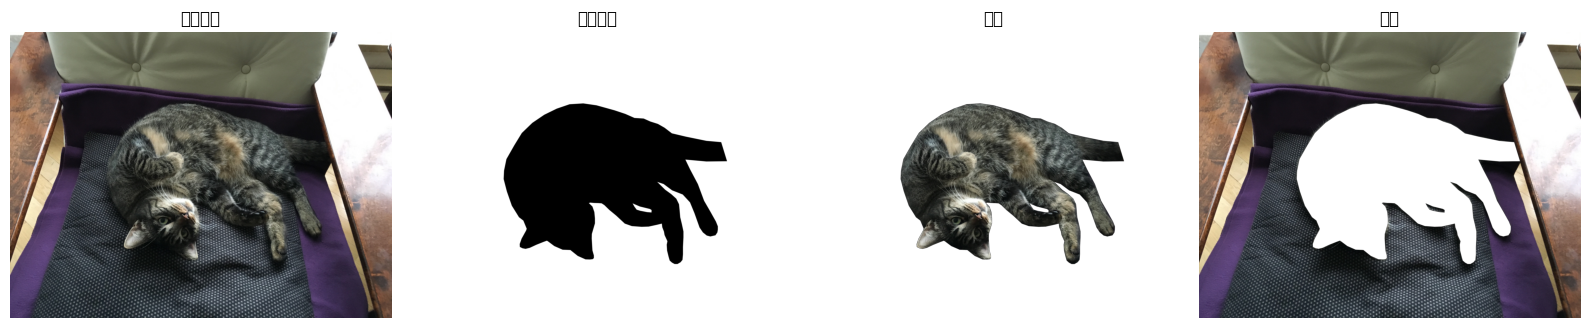

In [20]:
# 可视化第一张图像/遮罩对
data_index = 0

image = images[data_index]
mask = labels[data_index]

# 提取前景
foreground = Image.composite(image, mask, mask)

# 创建背景遮罩
mask_bg_np = np.copy(np.array(mask))
mask_bg_np[:, :, 3] = 255 - mask_bg_np[:, :, 3]
mask_bg = Image.fromarray(mask_bg_np)
background = Image.composite(image, mask_bg, mask_bg)

# 显示
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
data_to_show = [image, mask, foreground, background]
data_labels = ["原始图像", "前景遮罩", "前景", "背景"]

for i, (img, title) in enumerate(zip(data_to_show, data_labels)):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(title)

plt.tight_layout()
plt.show()

## 4. Patch 量化

由于模型使用 16x16 的 patch，我们需要将 ground truth 量化到 16x16 像素网格。

使用均匀 16x16 卷积作为 box blur 滤波器。

In [21]:
# 使用 processor 获取实际处理的图像大小
# 先用测试图像确定实际输出大小
test_img = Image.new('RGB', (256, 256))
test_inputs = processor(images=test_img, return_tensors='pt')
with torch.inference_mode():
    test_output = model(**test_inputs)
    ACTUAL_PATCHES = test_output.last_hidden_state.shape[1] - 1  # 减去 CLS token

PATCHES_PER_SIDE = int(ACTUAL_PATCHES ** 0.5)
IMAGE_SIZE = PATCHES_PER_SIDE * PATCH_SIZE  # 反推图像大小

print(f"模型实际输出: {ACTUAL_PATCHES} patches ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE})")
print(f"对应图像大小: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Patch 大小: {PATCH_SIZE}x{PATCH_SIZE}")

# 量化滤波器
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

def resize_transform(image, image_size=IMAGE_SIZE, patch_size=PATCH_SIZE):
    """调整图像到固定大小 (正方形)"""
    return TF.to_tensor(TF.resize(image, (image_size, image_size)))

模型实际输出: 256 patches (16x16)
对应图像大小: 256x256
Patch 大小: 16x16


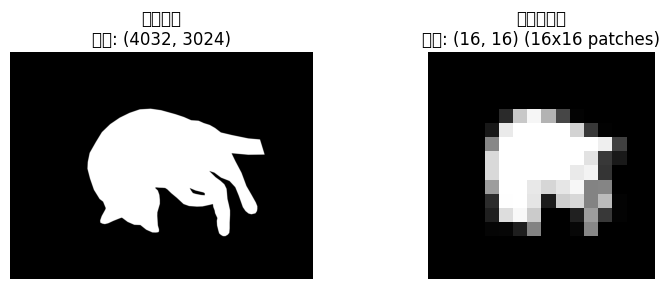

In [22]:
# 可视化量化效果
mask_0 = labels[0].split()[-1]  # 提取 alpha 通道
mask_0_resized = resize_transform(mask_0)

with torch.no_grad():
    mask_0_quantized = patch_quant_filter(mask_0_resized).squeeze()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(mask_0, cmap='gray')
axes[0].set_title(f"原始遮罩\n大小: {mask_0.size}")
axes[0].axis('off')
axes[1].imshow(mask_0_quantized, cmap='gray')
axes[1].set_title(f"量化后遮罩\n大小: {tuple(mask_0_quantized.shape)} ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE} patches)")
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 5. 提取特征和标签

遍历所有训练图像，提取每个 patch 的特征和标签。

In [23]:
# 使用 processor 自动处理图像
def extract_features_hf(image_pil):
    """使用 Hugging Face processor 和模型提取特征"""
    # processor 自动处理 resize 和 normalize
    inputs = processor(images=image_pil, return_tensors='pt')
    with torch.inference_mode():
        outputs = model(**inputs)
        # 去掉 CLS token
        patch_features = outputs.last_hidden_state[:, 1:, :]
        return patch_features.squeeze(0)  # [num_patches, dim]

TOTAL_PATCHES = PATCHES_PER_SIDE * PATCHES_PER_SIDE

# 收集所有特征和标签
xs = []  # 特征
ys = []  # 标签
image_indices = []

print(f"每张图像 patch 数量: {TOTAL_PATCHES} ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE})")
print("提取特征中...")

for i in tqdm(range(n_images), desc="处理图像"):
    # 加载图像和遮罩
    image_i = images[i].convert('RGB')
    mask_i = labels[i].split()[-1]
    
    # 遮罩量化 (使用相同的 IMAGE_SIZE)
    mask_i_resized = resize_transform(mask_i)
    mask_i_quantized = patch_quant_filter(mask_i_resized).squeeze().view(-1)
    
    # 验证 patch 数量
    assert mask_i_quantized.shape[0] == TOTAL_PATCHES, \
        f"Mask patches {mask_i_quantized.shape[0]} != expected {TOTAL_PATCHES}"
    
    ys.append(mask_i_quantized)
    
    # 使用 processor 和模型提取特征
    features = extract_features_hf(image_i)
    
    # 验证特征 patch 数量
    assert features.shape[0] == TOTAL_PATCHES, \
        f"Feature patches {features.shape[0]} != expected {TOTAL_PATCHES}"
    
    xs.append(features)
    
    image_indices.append(i * torch.ones(ys[-1].shape))

# 合并
xs = torch.cat(xs)
ys = torch.cat(ys)
image_indices = torch.cat(image_indices)

# 只保留明确的正/负标签
idx = (ys < 0.01) | (ys > 0.99)
xs = xs[idx]
ys = ys[idx]
image_indices = image_indices[idx]

print(f"\n特征矩阵大小: {xs.shape}")
print(f"标签向量大小: {ys.shape}")

每张图像 patch 数量: 256 (16x16)
提取特征中...


处理图像: 100%|██████████| 9/9 [00:02<00:00,  4.32it/s]


特征矩阵大小: torch.Size([1924, 384])
标签向量大小: torch.Size([1924])


## 6. 训练分类器

使用逻辑回归训练前景分割器。

采用 leave-one-out 交叉验证来选择最佳正则化参数 C。

In [24]:
# 测试不同的 C 值
cs = np.logspace(-7, 0, 8)
scores = np.zeros((n_images, len(cs)))

print("进行 leave-one-out 交叉验证...\n")

for i in range(n_images):
    print(f'验证图像 {i+1}/{n_images}')
    
    train_mask = image_indices != float(i)
    fold_x = xs[train_mask].numpy()
    fold_y = (ys[train_mask] > 0).long().numpy()
    val_x = xs[~train_mask].numpy()
    val_y = (ys[~train_mask] > 0).long().numpy()
    
    for j, c in enumerate(cs):
        clf = LogisticRegression(random_state=0, C=c, max_iter=10000).fit(fold_x, fold_y)
        output = clf.predict_proba(val_x)
        s = average_precision_score(val_y, output[:, 1])
        scores[i, j] = s

# 计算平均 AP
mean_scores = scores.mean(axis=0)
best_c_idx = np.argmax(mean_scores)
best_c = cs[best_c_idx]

print(f"\n最佳 C 值: {best_c:.1e}")
print(f"平均 AP: {mean_scores[best_c_idx]:.2%}")

进行 leave-one-out 交叉验证...

验证图像 1/9
验证图像 2/9
验证图像 3/9
验证图像 4/9
验证图像 5/9
验证图像 6/9
验证图像 7/9
验证图像 8/9
验证图像 9/9

最佳 C 值: 1.0e-03
平均 AP: 92.53%


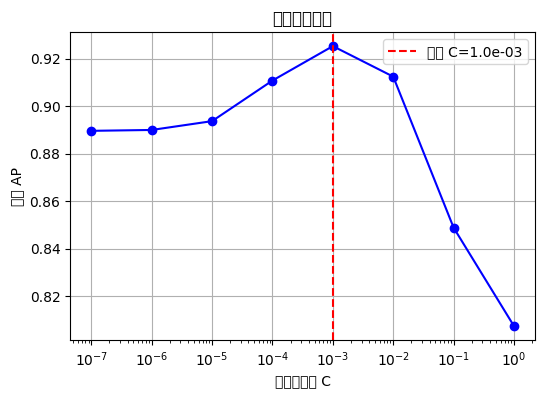

In [25]:
# 可视化交叉验证结果
plt.figure(figsize=(6, 4))
plt.plot(cs, mean_scores, 'bo-')
plt.xscale('log')
plt.xlabel('正则化参数 C')
plt.ylabel('平均 AP')
plt.title('交叉验证结果')
plt.axvline(x=best_c, color='r', linestyle='--', label=f'最佳 C={best_c:.1e}')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# 使用最佳 C 值训练最终模型
print(f"使用 C={best_c:.1e} 训练最终模型...")

clf = LogisticRegression(random_state=0, C=best_c, max_iter=10000)
clf.fit(xs.numpy(), (ys > 0).long().numpy())

print("✓ 模型训练完成!")

使用 C=1.0e-03 训练最终模型...
✓ 模型训练完成!


## 7. 测试推理

在测试图像上验证模型效果。

加载测试图像...


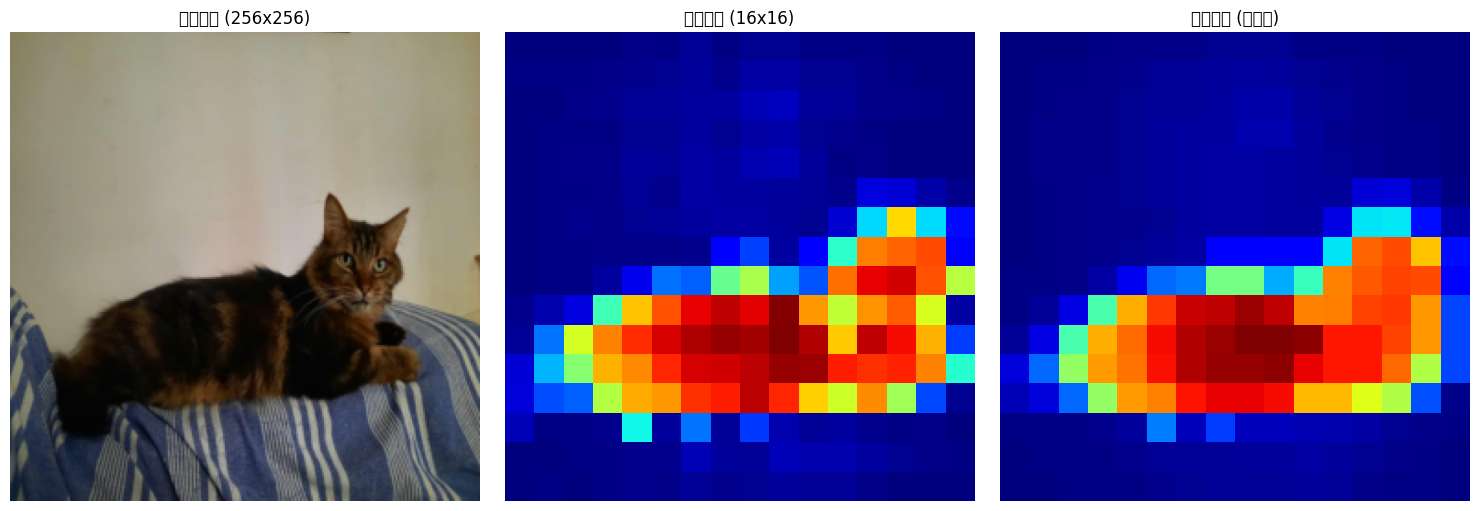

In [27]:
# 加载测试图像
test_image_url = "https://dl.fbaipublicfiles.com/dinov3/notebooks/foreground_segmentation/test_image.jpg"

def load_image_from_url(url: str) -> Image.Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")

print("加载测试图像...")
test_image = load_image_from_url(test_image_url)

# 使用 processor 和模型提取特征
test_features = extract_features_hf(test_image)

# 预测前景概率
fg_score = clf.predict_proba(test_features.numpy())[:, 1].reshape(PATCHES_PER_SIDE, PATCHES_PER_SIDE)

# 中值滤波平滑
fg_score_smoothed = signal.medfilt2d(fg_score, kernel_size=3)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 显示原图 (调整大小以匹配特征图)
test_resized = resize_transform(test_image)
axes[0].imshow(test_resized.permute(1, 2, 0))
axes[0].set_title(f'输入图像 ({IMAGE_SIZE}x{IMAGE_SIZE})')
axes[0].axis('off')

axes[1].imshow(fg_score, cmap='jet')
axes[1].set_title(f'前景概率 ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE})')
axes[1].axis('off')

axes[2].imshow(fg_score_smoothed, cmap='jet')
axes[2].set_title('前景概率 (平滑后)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 8. 保存模型

In [28]:
# 保存分类器
save_path = os.path.join('.', 'fg_classifier_cpu.pkl')

with open(save_path, "wb") as f:
    pickle.dump(clf, f)

print(f"✓ 模型已保存到: {save_path}")

✓ 模型已保存到: .\fg_classifier_cpu.pkl


## 9. 测试你自己的图片


处理图片: http://images.cocodataset.org/val2017/000000039769.jpg


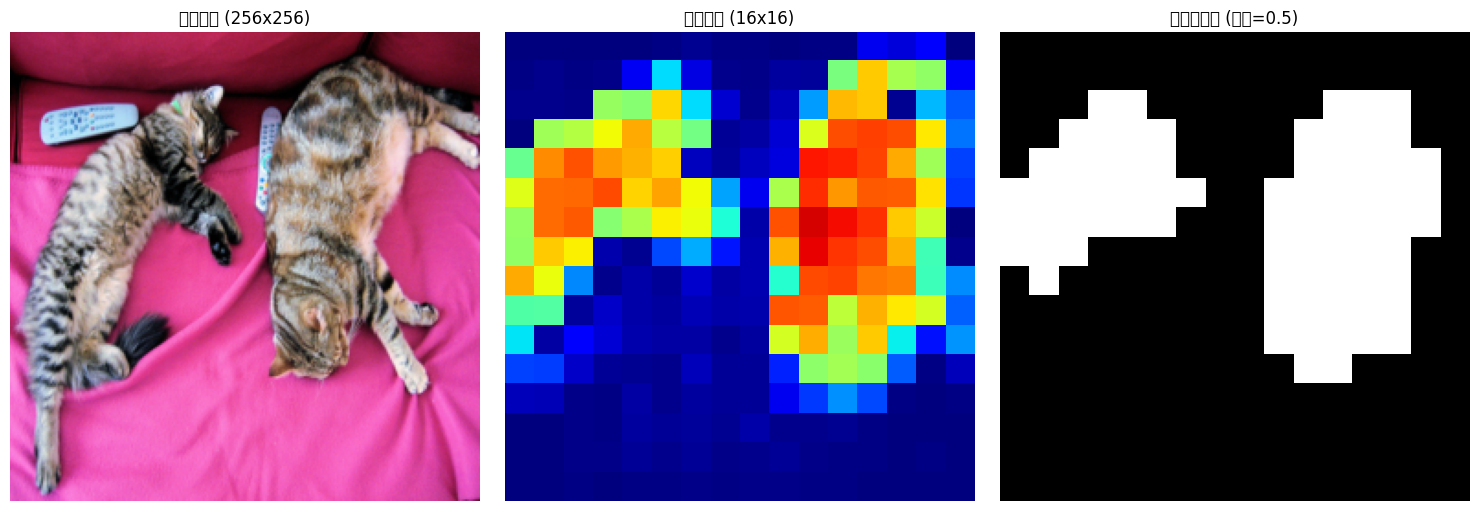

In [29]:
def predict_foreground(image_source, is_url=True):
    """对图片进行前景分割预测"""
    # 加载图片
    if is_url:
        img = load_image_from_url(image_source)
    else:
        img = Image.open(image_source).convert('RGB')
    
    # 使用 processor 和模型提取特征
    features = extract_features_hf(img)
    
    # 预测
    fg = clf.predict_proba(features.numpy())[:, 1].reshape(PATCHES_PER_SIDE, PATCHES_PER_SIDE)
    fg_smooth = signal.medfilt2d(fg, kernel_size=3)
    
    # 可视化
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 显示调整后的图像
    img_resized = resize_transform(img)
    axes[0].imshow(img_resized.permute(1, 2, 0))
    axes[0].set_title(f'输入图像 ({IMAGE_SIZE}x{IMAGE_SIZE})')
    axes[0].axis('off')
    
    axes[1].imshow(fg, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title(f'前景概率 ({PATCHES_PER_SIDE}x{PATCHES_PER_SIDE})')
    axes[1].axis('off')
    
    # 二值化结果
    binary_mask = (fg_smooth > 0.5).astype(float)
    axes[2].imshow(binary_mask, cmap='gray')
    axes[2].set_title('二值化遮罩 (阈值=0.5)')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return fg_smooth

# 测试示例
test_urls = [
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # 猫
]

for url in test_urls:
    print(f"\n处理图片: {url}")
    try:
        predict_foreground(url, is_url=True)
    except Exception as e:
        print(f"处理失败: {e}")

## 总结

恭喜！你已经成功训练了一个前景分割模型！

**关键学习点：**
1. DINO 模型提取的 patch 特征具有很强的语义信息
2. 即使是简单的线性分类器也能取得不错的效果
3. 线性探测 (Linear Probing) 是评估特征质量的好方法

**下一步学习：**
1. 尝试不同的图片
2. 比较不同模型 (ViT-B vs ViT-S)
3. 学习 `dense_sparse_matching.ipynb` - 图像匹配
4. 申请 DINOv3 权重，比较 v2 和 v3 的效果差异